In [1]:
import zipfile
import os

zip_path = "/content/keypointxyz.zip"  # Path to the copied ZIP file
extract_path = "/content/extracted"  # Destination folder

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed. Files are in:", extract_path)


Extraction completed. Files are in: /content/extracted


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



In [4]:
data = pd.read_csv('/content/extracted/keypointxyz.csv',header=None)

<ipython-input-4-bb8eb773c1f7>:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('/content/extracted/keypointxyz.csv',header=None)


In [5]:
data[0] = data[0].astype(str)

In [6]:
data[0].unique()

array(['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
       'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
       '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [7]:
X = data.iloc[:,1:]
X

,1,2,3,4,5,6,7,8,9,10,...,54,55,56,57,58,59,60,61,62,63
0,0.0,0.0,0.0,0.315789,-0.184211,-0.000921,0.657895,-0.421053,-0.001422,0.842105,...,-0.002556,0.210526,0.315789,-0.003148,0.157895,0.315789,-0.003077,0.052632,0.236842,-0.003109
1,0.0,0.0,0.0,-0.272727,-0.204545,-0.000697,-0.590909,-0.386364,-0.001351,-0.818182,...,-0.002653,-0.431818,0.272727,-0.003257,-0.363636,0.295455,-0.002998,-0.250000,0.250000,-0.002790
2,0.0,0.0,0.0,0.289474,-0.184211,-0.000974,0.631579,-0.394737,-0.001487,0.842105,...,-0.002651,0.157895,0.368421,-0.003270,0.105263,0.342105,-0.003223,0.000000,0.263158,-0.003275
3,0.0,0.0,0.0,-0.295455,-0.204545,-0.000751,-0.590909,-0.409091,-0.001425,-0.818182,...,-0.002661,-0.431818,0.250000,-0.003252,-0.363636,0.272727,-0.003040,-0.227273,0.204545,-0.002881
4,0.0,0.0,0.0,0.315789,-0.210526,-0.001033,0.631579,-0.394737,-0.001602,0.842105,...,-0.002776,0.184211,0.342105,-0.003443,0.131579,0.315789,-0.003372,0.026316,0.236842,-0.003413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57610,0.0,0.0,0.0,0.189189,0.256757,-0.001056,0.527027,0.405405,-0.001675,0.756757,...,-0.001185,0.756757,-0.635135,-0.001838,0.675676,-0.500000,-0.001496,0.621622,-0.405405,-0.001012
57611,0.0,0.0,0.0,0.189189,0.270270,-0.001100,0.513514,0.418919,-0.001782,0.756757,...,-0.001279,0.756757,-0.635135,-0.001935,0.675676,-0.500000,-0.001574,0.621622,-0.391892,-0.001078
57612,0.0,0.0,0.0,0.189189,0.283784,-0.001102,0.513514,0.432432,-0.001779,0.756757,...,-0.001257,0.756757,-0.621622,-0.001886,0.675676,-0.486486,-0.001504,0.621622,-0.378378,-0.001003
57613,0.0,0.0,0.0,0.202703,0.256757,-0.001295,0.513514,0.405405,-0.002150,0.756757,...,-0.001445,0.743243,-0.608108,-0.002165,0.675676,-0.500000,-0.001879,0.635135,-0.391892,-0.001444


In [8]:
enc = LabelEncoder()

In [9]:
y = enc.fit_transform(data[[0]])
y

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([9, 9, 9, ..., 8, 8, 8])

In [10]:
print(y)

[9 9 9 ... 8 8 8]


In [11]:
import numpy as np

label_counts = np.bincount(y)

# Display the counts for each label index
for label, count in enumerate(label_counts):
    if count > 0:  # Only print existing labels
        print(f"Label {label}: {count} samples")

Label 0: 1199 samples
Label 1: 1199 samples
Label 2: 1199 samples
Label 3: 1199 samples
Label 4: 1199 samples
Label 5: 1199 samples
Label 6: 1199 samples
Label 7: 1199 samples
Label 8: 1199 samples
Label 9: 2398 samples
Label 10: 2206 samples
Label 11: 1199 samples
Label 12: 2397 samples
Label 13: 2398 samples
Label 14: 2092 samples
Label 15: 2164 samples
Label 16: 1298 samples
Label 17: 1199 samples
Label 18: 1201 samples
Label 19: 2396 samples
Label 20: 1199 samples
Label 21: 2395 samples
Label 22: 2398 samples
Label 23: 1163 samples
Label 24: 1769 samples
Label 25: 841 samples
Label 26: 1454 samples
Label 27: 1925 samples
Label 28: 2388 samples
Label 29: 1220 samples
Label 30: 1199 samples
Label 31: 1199 samples
Label 32: 2398 samples
Label 33: 2286 samples
Label 34: 2042 samples


In [12]:
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=2)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [14]:
model1 = keras.Sequential([
    layers.Dense(1470, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(832, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(428, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(264, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(55, activation='softmax')
])

In [15]:
model1.compile(loss = "sparse_categorical_crossentropy", optimizer = "adam", metrics=["accuracy"])

In [16]:
model1.fit(X_train, y_train, epochs = 10, batch_size = 128, validation_split = 0.2)

Epoch 1/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 11s 20ms/step - accuracy: 0.3718 - loss: 2.2027 - val_accuracy: 0.9446 - val_loss: 0.1154
Epoch 2/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9185 - loss: 0.2353 - val_accuracy: 0.9890 - val_loss: 0.0450
Epoch 3/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9572 - loss: 0.1301 - val_accuracy: 0.9792 - val_loss: 0.0386
Epoch 4/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9659 - loss: 0.0959 - val_accuracy: 0.9920 - val_loss: 0.0260
Epoch 5/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9734 - loss: 0.0793 - val_accuracy: 0.9929 - val_loss: 0.0255
Epoch 6/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9760 - loss: 0.0701 - val_accuracy: 0.9914 - val_loss: 0.0262
Epoch 7/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9771 - loss: 0.0670 - val_accuracy: 0.9936 - val_loss: 0.0243
Epoch 8/10
289/289 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9783 - loss: 0.0634 - val_accuracy: 

In [17]:

model1.evaluate(X_test, y_test, verbose = 0)

[0.032696790993213654, 0.989846408367157]

In [ ]:
# evaluate the model on the validation set and compute performance metrics
y_val_pred = model1.predict(X_test)
y_val_pred_classes = np.argmax(y_val_pred, axis=1)
acc = accuracy_score(y_test, y_val_pred_classes)
prec = precision_score(y_test, y_val_pred_classes, average='macro')
rec = recall_score(y_test, y_val_pred_classes, average='macro')
f1 = f1_score(y_test, y_val_pred_classes, average='macro')
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1-score:", f1)

361/361 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy: 0.9949665885620064
Precision: 0.9955394692659268
Recall: 0.994223287289158
F1-score: 0.9946310728099776


In [19]:
from sklearn.ensemble import RandomForestClassifier

model3 = RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42)
model3.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

In [23]:
from xgboost import XGBClassifier

model5 = XGBClassifier(n_estimators=300, max_depth=10, learning_rate=0.05)
model5.fit(X_train, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=10, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [25]:
from sklearn.svm import SVC

model4 = SVC(kernel='rbf', C=1.0, probability=True)
model4.fit(X_train, y_train)


SVC(probability=True)

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


# Function to evaluate ML models
def evaluate_ml_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{model_name} Performance:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1-score: {f1:.4f}")


# Evaluate each ML model
evaluate_ml_model(model3, X_test, y_test, "Random Forest")
evaluate_ml_model(model4, X_test, y_test, "SVM")
evaluate_ml_model(model5, X_test, y_test, "XGBoost")



Random Forest Performance:
Accuracy: 0.9996
Precision: 0.9996
Recall: 0.9996
F1-score: 0.9996

SVM Performance:
Accuracy: 0.9948
Precision: 0.9950
Recall: 0.9948
F1-score: 0.9947

XGBoost Performance:
Accuracy: 0.9995
Precision: 0.9995
Recall: 0.9995
F1-score: 0.9995


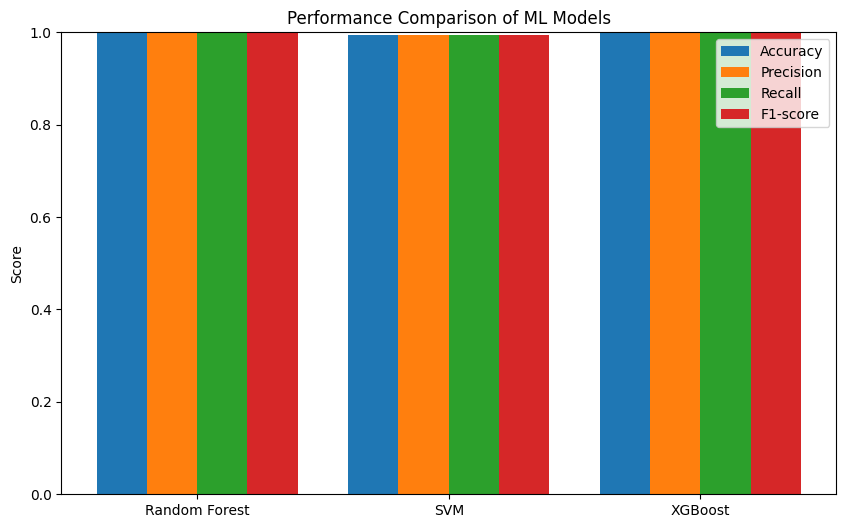

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Function to evaluate ML models and store results
def evaluate_ml_model(model, X_test, y_test, model_name, results):
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results[model_name] = [acc, prec, rec, f1]

# Dictionary to store results
results = {}

# Evaluate ML models
evaluate_ml_model(model3, X_test, y_test, "Random Forest", results)
evaluate_ml_model(model4, X_test, y_test, "SVM", results)
evaluate_ml_model(model5, X_test, y_test, "XGBoost", results)

# Convert results to NumPy array for easy plotting
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
models = list(results.keys())
values = np.array(list(results.values()))

# Plot results
fig, ax = plt.subplots(figsize=(10, 6))
bar_width = 0.2
x = np.arange(len(models))

for i in range(len(metrics)):
    plt.bar(x + i * bar_width, values[:, i], width=bar_width, label=metrics[i])

plt.xticks(x + bar_width * 1.5, models)
plt.ylabel("Score")
plt.ylim(0, 1)
plt.title("Performance Comparison of ML Models")
plt.legend()
plt.show()


In [28]:
model1.save("wordmodel3.h5")